# Decoradores

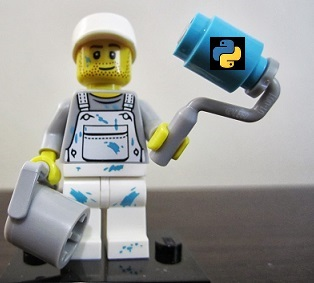

* Los decoradores son una característica de Python que **te permiten "decorar" o modificar funciones existentes de manera sencilla.**


* Puedes pensar en ellos como una forma de **"envoltorio"** que <font color='green'>**agrega funcionalidad adicional a una función** </font>**sin modificar su código original.**

Veamos esto comenzando con una función sencilla:

In [1]:
def saludar(nombre):
    print("Hola " + nombre)

saludar("Juan") # Imprime "Hola Juan"


Hola Juan


## Definiendo Decoradores

Los decoradores se definen usando el simbolo **@, seguida del nombre del decorador y una función.** 

Veamos un ejemplo de cómo se puede usar un decorador para agregar funcionalidad a una función existente:

In [4]:
def decir_hola(func):
    def envoltorio(*args, **kwargs):
        print("Hola!")
        func(*args, **kwargs)
        print("Adios")
    return envoltorio

@decir_hola
def saludar(nombre):
    print("Hola " + nombre)

saludar("Juan") 
# Imprime "Hola!" y luego "Hola Juan"


Hola!
Hola Juan
Adios


En este ejemplo, **el decorador** <font color='blue'>**decir_hola** </font> toma como parámetro la función saludar y devuelve una nueva función (llamada envoltorio) que **agrega la funcionalidad adicional de imprimir "Hola!" antes de llamar a la función original.** 


<font color='green'>**La notación @decir_hola se coloca justo encima de la definición de la función saludar,**</font> lo que indica que **se debe aplicar el decorador a esa función.**



**Los decoradores pueden ser útiles en varios casos, como por ejemplo:**

- Para agregar funcionalidad a una función existente sin tener que modificar su código original.


- Para validar los argumentos de una función antes de llamarla.


- Para medir el tiempo que tarda una función en ejecutarse.


- Para implementar un sistema de caché que almacene los resultados de una función para evitar tener que volver a calcularlos cada vez que se llame a la función.

* **Medir el tiempo de ejecución de una función**

En este ejemplo, usamos un decorador para medir el tiempo que tarda una función en ejecutarse y mostrar el resultado en pantalla:

In [5]:
from time import time

def tiempo_de_ejecucion(func):
    def envoltorio(*args, **kwargs):
        inicio = time()
        resultado = func(*args, **kwargs)
        fin = time()
        print(f"La función {func.__name__} tardó {fin - inicio} segundos en ejecutarse.")
        return resultado
    return envoltorio

@tiempo_de_ejecucion
def cuadrado(x):
    return x ** 2

cuadrado(5) # Imprime "La función cuadrado tardó 0.000001 segundos en ejecutarse." y devuelve 25


La función cuadrado tardó 0.0 segundos en ejecutarse.


25

* **Sistema de Caché**

En este ejemplo, usamos un decorador para implementar un sistema de caché que almacena los resultados de una función para evitar tener que volver a calcularlos cada vez que se llama a la función:

In [8]:
def cache(func):
    resultados = {}
  
    def wrapper(*args, **kwargs):
        key = str(args) + str(kwargs)
        if key in resultados:
            return resultados[key]
        resultado = func(*args, **kwargs)
        resultados[key] = resultado
        return resultado
  
    return wrapper

@cache
def factorial(n):
    if n <= 1:
        return 1
    return n * factorial(n - 1)

factorial(5) # Calcula el factorial de 5 y devuelve 120
factorial(5) # Devuelve el valor cacheado de 120 sin tener que volver a calcularlo


120


120

**Ejemplo de un decorador que se puede usar para implementar un sistema de autenticación en una aplicación web.**

El decorador valida que el usuario que intenta acceder a una página esté registrado y haya iniciado sesión antes de permitirle acceder a la página:

In [ ]:
from django.shortcuts import redirect

def autenticar(func):
    def envoltorio(request):
        if not request.user.is_authenticated:
            return redirect("/login")
        return func(request)
    return envoltorio

@autenticar
def perfil(request):
    # Esta página solo puede ser accedida por usuarios autenticados
    usuario = request.user
    nombre_completo = usuario.first_name + " " + usuario.last_name
    context = {"nombre_completo": nombre_completo}
    return render(request, "perfil.html", context)


En este ejemplo, se usa Django para manejar la lógica del servidor y generar la página de perfil. 

La función perfil toma un objeto request que contiene información sobre la solicitud del usuario, como por ejemplo si está autenticado o no. Si el usuario está autenticado, se obtiene su nombre completo a partir de sus campos first_name y last_name y se pasa al archivo HTML que contiene la plantilla de la página de perfil. La plantilla usa esa información para mostrar el nombre del usuario en la página.

## Ejercicios

1. **Implementar una función que calcule el promedio de una lista de números y utilizar un decorador para validar que la lista no esté vacía antes de calcular el promedio.**

**Tareas:**

1. Definir una función `promedio(lista)` que calcule el promedio de una lista de números. La función debe devolver el promedio como un valor de punto flotante.

2. Definir un decorador `validar_lista_no_vacia` que tome como parámetro la función promedio y valide que la lista de números no esté vacía antes de llamar a la función promedio. Si la lista está vacía, el decorador debe lanzar una excepción ValueError con el mensaje "La lista no puede estar vacía".

3. Aplicar el decorador `validar_lista_no_vacia` a la función `promedio` usando la notación @ y probar la función con diferentes listas de números.

In [ ]:
# Creamos la funcion decorador para validar si la lista
# esta vacia
def validar_lista_no_vacia(func):
    def wrapper(lista):
        # Comprobamos que la lista esta vacia
        if len(lista) == 0:
            # Devolvemos un mensaje de error
            raise ValueError('La lista no puede estar vacía')
        
        # Sino llamamos a la funcion de promedio
        return func(lista)
    return wrapper

# Aplicamos el decorador
@validar_lista_no_vacia
# Funcion para obtener el promedio de la lista
def promedio(lista):
    return sum(lista)/len(lista)

# Probamos la funcion con dos casos
# Lista con elementos
lista1 = [1, 2, 3, 4, 5]
try:
    print(promedio(lista1))
except ValueError as error:
    print(f'Error: {error}')
# Lista vacia
lista2 = []
try:
    print(promedio(lista2))
except ValueError as error:
    print(f'Error: {error}')